# Phase II — Exploratory Data Analysis

**Project GitHub repository:** https://github.com/VincentPit/ds_in_da_wild

**Collaborators:** Junyi Li (jl4724), Jinyue Wang (jw2796), Wenzhuo Zhang (wz475), Qiaohao Hu (qh252)

**Submitted:** March 18, 2026

## 1) Research Questions

**Primary question:**
How is daily roadway traffic volume associated with motor vehicle collision frequency and injury severity in NYC?

**Sub-questions:**
1. On high-traffic days, are there systematically more crashes, injuries, and fatalities — even after controlling for day-of-week and seasonal patterns in traffic volume?
2. Does the mix of crash victims (pedestrians vs. cyclists vs. motorists) shift on higher-traffic days, suggesting that volume disproportionately endangers vulnerable road users?
3. Does ambient street-level temperature modify the traffic–crash relationship — i.e., do high-volume days become even more dangerous at temperature extremes?
4. Do the volume–crash and volume–injury associations vary across boroughs, indicating that some areas bear a disproportionate share of crash risk per unit of traffic?
5. What day-of-week and seasonal cycles characterize both traffic volume and crash outcomes, and must be controlled for when isolating the volume effect?


## 2) Data Description

We draw on three Phase I datasets and one additional weather reanalysis source. The NYC Climate Projections dataset (decadal projections, no daily granularity) is not used.

---

### Dataset 1: NYC DOT Automated Traffic Volume Counts (ATVC)
**Source:** NYC Open Data — Socrata ID `7ym2-wayt`
**Cached data:** `data/atvc_daily.csv` (city-wide daily totals), `data/atvc_boro_daily.csv` (borough-level daily totals)

- **Why we use it:** Provides continuous daily traffic volume coverage from 2012 through 2025 — the primary exposure measure for the daily crash panel. Unlike the periodic spot-count surveys in Dataset 1b, ATVC records are submitted at 15-minute intervals from permanent and seasonal ATR sensors, yielding an uninterrupted time series.
- **Rows:** ~1.84 million (15-minute segment-level counts); aggregated to ~3,905 city-wide daily rows and ~6,674 borough-level daily rows for analysis.
- **Columns:** `boro`, `segmentid`, `yr`, `m`, `d`, `vol`, among others; aggregated to `Date`, `daily_vol`, and `n_segments`.
- **Why it was created:** NYC DOT operates permanent and portable ATR sensors to monitor traffic patterns for infrastructure planning, signal timing optimisation, and safety analysis.
- **Funding:** NYC Department of Transportation.
- **Potential biases:** Sensor placement is uneven across boroughs and road types; expressways and major arterials are overrepresented relative to local streets. Counts reflect vehicle passages at a fixed point, not vehicle-miles-travelled (VMT). Periods of sensor outage are absent from the dataset rather than imputed.
- **Preprocessing:** 15-minute counts aggregated to daily totals by `Date` and by `Date × boro`; `vol_per_segment` = `daily_vol / n_segments` computed as a sensor-density-normalised traffic intensity metric.
- **People involved:** No personal data collected; drivers are not aware their vehicles are being counted through passive roadway sensors.

---

### Dataset 1b: Traffic Volume Counts (Historical, Spot-Count)
**Source:** NYC Open Data — ID `btm5-ppia`
**Raw data:** `data/Traffic_Volume_Counts_(Historical)_20260225.csv`

- **Role in analysis:** Used *only* for **intra-day hourly profiling** in Section 4.11 (Sub-question 5). Contains 24 named hourly count columns (`12:00-1:00 AM` … `11:00-12:00 AM`) not present in the ATVC dataset.
- **Rows:** 42,756. Each row is one road-segment/direction on one survey date; covers 608 unique survey dates, Jan 2012 – May 2021.
- **Not used for the daily regression panel** — Dataset 1 (ATVC, `7ym2-wayt`) is the primary traffic source for all date-level analyses.

---

### Dataset 2: Motor Vehicle Collisions – Crashes
**Source:** NYC Open Data — ID `h9gi-nx95`
**Raw data:** `data/Motor_Vehicle_Collisions_-_Crashes_20260225.csv`

- **Why we use it:** Provides the outcome variable — crash frequency and severity — that we want to explain using traffic volume and temperature.
- **Rows:** 2,244,212. Each row is one reported collision.
- **Columns (29):** `COLLISION_ID`, `CRASH DATE`, `CRASH TIME`, `BOROUGH`, `ZIP CODE`, `LATITUDE`, `LONGITUDE`, injury/fatality counts split by pedestrian/cyclist/motorist, up to 5 contributing factors, and up to 5 vehicle types.
- **Columns used:** `COLLISION_ID` (for crash counts), `CRASH DATE`, `BOROUGH`, `LATITUDE`, `LONGITUDE`, `NUMBER OF PERSONS INJURED/KILLED`, `NUMBER OF PEDESTRIANS/CYCLISTS/MOTORISTS INJURED`. Covers Jul 2012 – Feb 2026.
- **Why it was created:** NYPD is required to file a report for every collision involving injury, death, or property damage over $1,000.
- **Funding:** NYPD / NYC Open Data initiative.
- **Potential biases:** Under-reporting likely for minor property-damage-only crashes. Geocoding failures produce missing lat/lon. Borough assignment missing in ~10% of rows. Reporting practices may have changed over time.
- **Preprocessing:** `CRASH DATE` parsed to datetime; all injury/fatality count columns coerced to numeric with `NaN → 0`; aggregated to daily crash count, total injuries, and total fatalities; `injuries_per_crash` and `fatalities_per_crash` computed.
- **People involved:** Crash records involve real individuals. Data is anonymised (no names); released as open government data.

---

### Dataset 3: Hyperlocal Temperature Monitoring
**Source:** NYC Open Data
**Raw data:** `data/Hyperlocal_Temperature_Monitoring_20260225.csv`

- **Why we use it:** Supplementary temperature series to explore whether extreme heat or cold modifies the traffic–crash relationship during the sensor deployment window.
- **Rows:** 2,097,150. Each row is one hourly air-temperature reading from one sensor on one date.
- **Columns (10):** `Sensor.ID`, `AirTemp` (°F), `Day`, `Hour`, `Latitude`, `Longitude`, `Year`, `Install.Type`, `Borough`, `ntacode`.
- **Columns used:** `Day`, `AirTemp`. Covers 423 sensors across Brooklyn, Bronx, Manhattan, and Queens, Jun 2018 – Oct 2019 only.
- **Why it was created:** NYC studied street-level urban heat island effects using low-cost sensors on street trees and light poles — distinct from airport-based weather stations.
- **Funding:** NYC Parks & Recreation / urban heat island research program.
- **Potential biases:** Staten Island has no sensor coverage. Sensors near trees may read differently from open-road sensors. The 15-month window (summer-heavy) is not a representative annual sample.
- **Preprocessing:** `Day` parsed to datetime; `AirTemp` averaged across all active sensors per day to produce `hyperlocal_temp_daily_avg`.
- **People involved:** No personal data. Sensors are passive environmental monitors.

---

### Dataset 4: Open-Meteo ERA5 Reanalysis Weather
**Source:** Open-Meteo ERA5 archive API (`archive-api.open-meteo.com/v1/archive`); no API key required
**Data:** Dynamically fetched for NYC coordinates (40.7128°N, 74.0060°W) across the full analysis window

- **Why we use it:** The hyperlocal temperature dataset (Dataset 3) covers only a 15-month summer-heavy window, insufficient for a full-panel weather analysis. ERA5 provides daily mean temperature (°F) and total precipitation (mm) for NYC across the full 2012–2025 panel, giving complete weather coverage for all 3,739 analysis days.
- **Rows per analysis run:** ~4,912 daily rows (one per calendar day across the full ATVC panel range).
- **Why it was created:** ERA5 is a global atmospheric reanalysis produced by the European Centre for Medium-Range Weather Forecasts (ECMWF), combining historical observations with numerical model forecasts to produce spatially and temporally consistent climate records.
- **Funding:** European Centre for Medium-Range Weather Forecasts (ECMWF); openly distributed via the Copernicus Climate Change Service.
- **Potential biases:** ERA5 values are model-derived estimates on a ~31 km grid, not direct measurements at street level. Urban heat island effects and hyperlocal precipitation variability within NYC are not fully captured. Data quality varies across decades as observation network density changed.
- **Preprocessing:** API response parsed to pandas DataFrame; `temperature_2m_max` and `temperature_2m_min` averaged and converted to Fahrenheit; `precipitation_sum` retained in mm; left-joined to the daily panel on `Date`.
- **People involved:** No personal data; ERA5 is a publicly available gridded reanalysis product.


## 3) Data Collection & Cleaning

All raw CSV files were downloaded from NYC Open Data on February 25, 2026 and stored in the `data/` folder. The full ingestion and merge pipeline runs in the setup cell below — **no pre-built CSV is used**. Traffic data are sourced from the NYC DOT ATVC dataset (Socrata `7ym2-wayt`), cached locally as `data/atvc_daily.csv` and `data/atvc_boro_daily.csv`.

**Pipeline summary:**
1. **Traffic Volume (ATVC)** — `data/atvc_daily.csv` loaded (or fetched from Socrata if absent); `daily_vol` and `n_segments` coerced to numeric; `vol_per_segment` = `daily_vol / n_segments` computed for sensor-density normalisation. The historical spot-count CSV (`btm5-ppia`) is loaded separately only to extract the 24 hourly count column names needed for Q5 intra-day profiling.
2. **Motor Vehicle Collisions** — `CRASH DATE` parsed to datetime; all eight injury/fatality count columns coerced to numeric with `NaN → 0`; aggregated to daily crash count, total injuries, and total fatalities.
3. **Hyperlocal Temperature** — `Day` parsed to datetime; `AirTemp` averaged across all active sensors per day → `hyperlocal_temp_daily_avg`.
4. **Merge** — ATVC daily totals and crash daily aggregates joined via **inner join** on `Date` (effective window: Jul 2012 – Dec 2025, yielding 3,739 rows). Hyperlocal temperature left-joined, yielding `NaN` outside the sensor window (Jun 2018 – Oct 2019).
5. **Derived features** — `injuries_per_crash`, `fatalities_per_crash`, and `vol_per_segment` (`daily_vol / n_segments`) computed on the merged frame.
6. **Calendar features** — `day_of_week`, `month`, `year`, `is_weekend`, `quarter` added at load time.

**Note on temperature coverage:** The hyperlocal sensor window (Jun 2018 – Oct 2019) covers only a fraction of the analysis panel. Temperature analysis in Section 4.7 therefore uses **Open-Meteo ERA5 reanalysis data** dynamically fetched for the full panel window (Jul 2012 – Dec 2025), providing 100% weather coverage across all 3,739 days.


## 4) Exploratory Data Analysis

All three raw datasets are loaded and merged directly from `data/` in the setup cell below. Calendar features (`day_of_week`, `month`, `year`, `is_weekend`, `quarter`) are added at load time. Each subsection maps to one of the five supporting sub-questions from Section 1:

| Section | Sub-question addressed |
|---|---|
| 4.2 Time-Series Overview | Background context — seasonal structure motivating Q5 controls |
| 4.3 Day-of-Week & Seasonal Patterns | **Q5** — What calendar cycles must be controlled for? |
| 4.4 Traffic Volume vs. Crashes | **Q1** — Do high-traffic days have more crashes/injuries? |
| 4.5 Victim Mix by Traffic Volume | **Q2** — Does victim mix shift on high-traffic days? |
| 4.6 Borough-Level Crash Patterns | **Q4** — Do crash outcomes vary across boroughs? |
| 4.7 Temperature Sub-Analysis | **Q3** — Does temperature modify the volume–crash link? |
| 4.8–4.9 Regression Models | **Q1** (continued) — Regression evidence for the volume effect |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

data_dir = Path('data')

# ── 1a. NYC DOT Automated Traffic Volume Counts (continuous, 2012-present) ────
# Dataset 7ym2-wayt: 15-min interval counts, native boro field, ~1.8 M rows.
# We use a pre-cached daily-aggregate CSV; if missing we fetch it from Socrata.
print("Loading ATVC daily traffic data...")
_atvc_cache = data_dir / 'atvc_daily.csv'
if _atvc_cache.exists():
    traffic_daily = pd.read_csv(_atvc_cache, parse_dates=['Date'])
    print(f"  Loaded from cache: {len(traffic_daily):,} rows")
else:
    import requests as _req
    print("  Cache not found — fetching from Socrata API (7ym2-wayt)…")
    _rows, _off, _lim = [], 0, 50_000
    while True:
        _r = _req.get(
            "https://data.cityofnewyork.us/resource/7ym2-wayt.json",
            params={
                "$select": "yr,m,d,sum(vol) as daily_vol,count(distinct segmentid) as n_segments",
                "$where":  "yr >= '2012'",
                "$group":  "yr,m,d",
                "$order":  "yr,m,d",
                "$limit":  _lim,
                "$offset": _off,
            }, timeout=60)
        _batch = _r.json()
        _rows.extend(_batch)
        if len(_batch) < _lim:
            break
        _off += _lim
    _atvc = pd.DataFrame(_rows)
    _atvc['Date'] = pd.to_datetime(
        _atvc[['yr', 'm', 'd']].rename(columns={'yr': 'year', 'm': 'month', 'd': 'day'}))
    _atvc['daily_vol']  = _atvc['daily_vol'].astype(float)
    _atvc['n_segments'] = _atvc['n_segments'].astype(int)
    traffic_daily = _atvc[['Date', 'daily_vol', 'n_segments']].copy()
    traffic_daily.to_csv(_atvc_cache, index=False)
    print(f"  Fetched and cached {len(traffic_daily):,} rows")

traffic_daily = traffic_daily.rename(columns={
    'daily_vol':  'total_daily_volume',
    'n_segments': 'traffic_segment_rows',
})
traffic_daily['Date'] = pd.to_datetime(traffic_daily['Date'])
print(f"  ATVC: {len(traffic_daily):,} days  |  "
      f"{traffic_daily['Date'].min().date()} → {traffic_daily['Date'].max().date()}")

# ── 1b. Historical traffic CSV — kept only for within-day hourly profiles ─────
print("Loading historical traffic CSV for hourly profiles…")
traffic_raw = pd.read_csv(next(data_dir.glob('Traffic_Volume_Counts*')))
traffic_raw['Date'] = pd.to_datetime(traffic_raw['Date'], errors='coerce')
traffic_raw = traffic_raw.dropna(subset=['Date'])
hour_cols = [c for c in traffic_raw.columns if ':' in c]
for c in hour_cols:
    traffic_raw[c] = pd.to_numeric(traffic_raw[c], errors='coerce').fillna(0)
traffic_raw['daily_volume'] = traffic_raw[hour_cols].sum(axis=1)
print(f"  {len(hour_cols)} hourly columns detected (used for Q5 only)")

# ── 2. Motor Vehicle Collisions ───────────────────────────────────────────────
print("Loading crash data...")
crashes_raw = pd.read_csv(
    next(data_dir.glob('Motor_Vehicle_Collisions*')), low_memory=False,
    usecols=['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'COLLISION_ID',
             'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
             'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED',
             'NUMBER OF MOTORIST INJURED', 'LATITUDE', 'LONGITUDE']
)
crashes_raw['CRASH DATE'] = pd.to_datetime(crashes_raw['CRASH DATE'], errors='coerce')
for c in ['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
          'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED',
          'NUMBER OF MOTORIST INJURED']:
    crashes_raw[c] = pd.to_numeric(crashes_raw[c], errors='coerce').fillna(0)

crash_daily = (
    crashes_raw.groupby('CRASH DATE')
    .agg(
        daily_crashes=('COLLISION_ID', 'count'),
        persons_injured=('NUMBER OF PERSONS INJURED', 'sum'),
        persons_killed=('NUMBER OF PERSONS KILLED', 'sum'),
    )
    .reset_index()
    .rename(columns={'CRASH DATE': 'Date'})
)
print(f"  Crashes: {len(crash_daily):,} days  |  "
      f"{crash_daily['Date'].min().date()} → {crash_daily['Date'].max().date()}")

# ── 3. Hyperlocal Temperature ─────────────────────────────────────────────────
print("Loading hyperlocal temperature data...")
hyperlocal_raw = pd.read_csv(
    next(data_dir.glob('Hyperlocal_Temperature*')),
    usecols=['Day', 'AirTemp']
)
hyperlocal_raw['Day'] = pd.to_datetime(hyperlocal_raw['Day'], errors='coerce')
hyperlocal_raw['AirTemp'] = pd.to_numeric(hyperlocal_raw['AirTemp'], errors='coerce')
hyperlocal_daily = (
    hyperlocal_raw.dropna(subset=['Day', 'AirTemp'])
    .groupby('Day')['AirTemp'].mean()
    .reset_index()
    .rename(columns={'Day': 'Date', 'AirTemp': 'hyperlocal_temp_daily_avg'})
)
print(f"  Hyperlocal: {len(hyperlocal_daily):,} days  |  "
      f"{hyperlocal_daily['Date'].min().date()} → {hyperlocal_daily['Date'].max().date()}")

# ── 4. Merge all three datasets ───────────────────────────────────────────────
df = traffic_daily.merge(crash_daily, on='Date', how='inner')
df = df.merge(hyperlocal_daily, on='Date', how='left')

# Derived rate features
df['injuries_per_crash']   = (df['persons_injured']
                               / df['daily_crashes'].replace(0, np.nan))
df['fatalities_per_crash'] = (df['persons_killed']
                               / df['daily_crashes'].replace(0, np.nan))
df['vol_per_segment']      = (df['total_daily_volume']
                               / df['traffic_segment_rows'].replace(0, np.nan))

df = df.sort_values('Date').reset_index(drop=True)

# ── 5. Calendar features ──────────────────────────────────────────────────────
df['year']        = df['Date'].dt.year
df['month']       = df['Date'].dt.month
df['month_name']  = df['Date'].dt.strftime('%b')
df['day_of_week'] = df['Date'].dt.day_name()
df['dow_num']     = df['Date'].dt.dayofweek          # 0=Mon … 6=Sun
df['is_weekend']  = df['dow_num'].isin([5, 6]).astype(int)
df['quarter']     = df['Date'].dt.quarter

print(f"\nMerged df: {len(df):,} rows  |  "
      f"{df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Hyperlocal coverage: {df['hyperlocal_temp_daily_avg'].notna().sum()} / {len(df)} days")
print(f"Columns: {list(df.columns)}")
df.head(3)


Loading ATVC daily traffic data...
  Loaded from cache: 3,905 rows
  ATVC: 3,905 days  |  2012-01-07 → 2025-12-11
Loading historical traffic CSV for hourly profiles…
  24 hourly columns detected (used for Q5 only)
Loading crash data...
  Crashes: 4,984 days  |  2012-07-01 → 2026-02-21
Loading hyperlocal temperature data...
  Hyperlocal: 246 days  |  2018-06-15 → 2019-10-15

Merged df: 3,739 rows  |  2012-07-01 → 2025-12-11
Hyperlocal coverage: 193 / 3739 days
Columns: ['Date', 'total_daily_volume', 'traffic_segment_rows', 'daily_crashes', 'persons_injured', 'persons_killed', 'hyperlocal_temp_daily_avg', 'injuries_per_crash', 'fatalities_per_crash', 'vol_per_segment', 'year', 'month', 'month_name', 'day_of_week', 'dow_num', 'is_weekend', 'quarter']


,Date,total_daily_volume,traffic_segment_rows,daily_crashes,persons_injured,persons_killed,hyperlocal_temp_daily_avg,injuries_per_crash,fatalities_per_crash,vol_per_segment,year,month,month_name,day_of_week,dow_num,is_weekend,quarter
0,2012-07-01,44390.0,4,538,166.0,0.0,NaN,0.308550,0.000000,11097.50,2012,7,Jul,Sunday,6,1,3
1,2012-07-02,55663.0,4,564,175.0,1.0,NaN,0.310284,0.001773,13915.75,2012,7,Jul,Monday,0,0,3
2,2012-07-03,64154.0,4,664,210.0,1.0,NaN,0.316265,0.001506,16038.50,2012,7,Jul,Tuesday,1,0,3


In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "requests"])
import requests

# ── Fetch NYC daily weather from Open-Meteo (free ERA5 archive, no API key) ──
# Date range derived from df so it always covers the full panel.
_start = df["Date"].min().strftime("%Y-%m-%d")
_end   = df["Date"].max().strftime("%Y-%m-%d")

print(f"Fetching daily weather for NYC from Open-Meteo archive ({_start} → {_end})...")
try:
    resp = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude":         40.7128,
            "longitude":        -74.0060,
            "start_date":       _start,
            "end_date":         _end,
            "daily":            "temperature_2m_mean,precipitation_sum",
            "temperature_unit": "fahrenheit",
            "timezone":         "America/New_York",
        },
        timeout=30,
    )
    wdata = resp.json()["daily"]
    weather_df = pd.DataFrame({
        "Date":        pd.to_datetime(wdata["time"]),
        "temp_mean_F": wdata["temperature_2m_mean"],
        "precip_mm":   wdata["precipitation_sum"],
    })
    # Drop stale weather cols if this cell is re-run
    df.drop(columns=["temp_mean_F", "precip_mm"], errors="ignore", inplace=True)
    df = df.merge(weather_df, on="Date", how="left")
    print(f"Weather fetched:  {len(weather_df):,} days")
    print(f"Merged into df — temp coverage:   {df['temp_mean_F'].notna().sum()}/{len(df)} days")
    print(f"               — precip coverage: {df['precip_mm'].notna().sum()}/{len(df)} days")
except Exception as e:
    print(f"⚠  Weather fetch failed: {e}")
    df["temp_mean_F"] = np.nan
    df["precip_mm"]   = np.nan

df[["Date", "temp_mean_F", "precip_mm"]].head(3)


Fetching daily weather for NYC from Open-Meteo archive (2012-07-01 → 2025-12-11)...
Weather fetched:  4,912 days
Merged into df — temp coverage:   3739/3739 days
               — precip coverage: 3739/3739 days


,Date,temp_mean_F,precip_mm
0,2012-07-01,81.6,1.7
1,2012-07-02,78.5,0.0
2,2012-07-03,78.7,0.0


### 4.1 Summary Statistics

Before plotting anything, we examine the basic distribution of our main variables. This helps us understand the typical range of daily crashes and traffic volume, spot any unusual outliers, and decide whether any transformations are needed.


In [3]:
core_cols = ['total_daily_volume', 'daily_crashes', 'persons_injured',
             'persons_killed', 'injuries_per_crash', 'fatalities_per_crash',
             'hyperlocal_temp_daily_avg']

summary = df[core_cols].describe().T
summary['missing'] = df[core_cols].isna().sum()
summary['missing_pct'] = (summary['missing'] / len(df) * 100).round(1)
summary

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
total_daily_volume,3739.0,41642.444771,44083.269344,0.000000,16904.000000,30464.000000,48972.500000,436874.000000,0,0.0
daily_crashes,3739.0,495.687884,171.651520,147.000000,311.000000,535.000000,629.500000,1161.000000,0,0.0
persons_injured,3739.0,153.503076,30.642097,47.000000,133.000000,153.000000,173.000000,311.000000,0,0.0
persons_killed,3739.0,0.725863,0.921767,0.000000,0.000000,0.000000,1.000000,10.000000,0,0.0
injuries_per_crash,3739.0,0.348079,0.133800,0.109639,0.248667,0.289157,0.463619,0.777344,0,0.0
fatalities_per_crash,3739.0,0.001703,0.002413,0.000000,0.000000,0.000000,0.002886,0.020408,0,0.0
hyperlocal_temp_daily_avg,193.0,74.859369,7.411211,53.159635,71.255264,75.565644,80.398235,92.324375,3546,94.8


In [4]:
# Check for overdispersion in daily_crashes: if variance >> mean, Negative Binomial is warranted
mean_crashes = df['daily_crashes'].mean()
var_crashes  = df['daily_crashes'].var()
print(f"daily_crashes  mean: {mean_crashes:.1f}")
print(f"daily_crashes  var:  {var_crashes:.1f}")
print(f"Dispersion ratio (var/mean): {var_crashes/mean_crashes:.2f}  — values >> 1 suggest overdispersion")

daily_crashes  mean: 495.7
daily_crashes  var:  29464.2
Dispersion ratio (var/mean): 59.44  — values >> 1 suggest overdispersion


**Interpretation:** `daily_crashes` has a mean around 500–600 and a variance many times larger, indicating strong overdispersion. This is consistent with Poisson being an inadequate distributional assumption for this count outcome — a Negative Binomial model may be more appropriate for Phase III. Formal model comparison is carried out in Section 4.9.


### 4.2 Time-Series Overview: Traffic Volume & Crashes

**Context for Sub-questions 1 & 5:** We plot the full time series to see whether volume and crashes move together over time and how strong the seasonal cycle is. These features motivate why the volume–crash relationship must be examined after accounting for calendar structure (Q1, Q5).


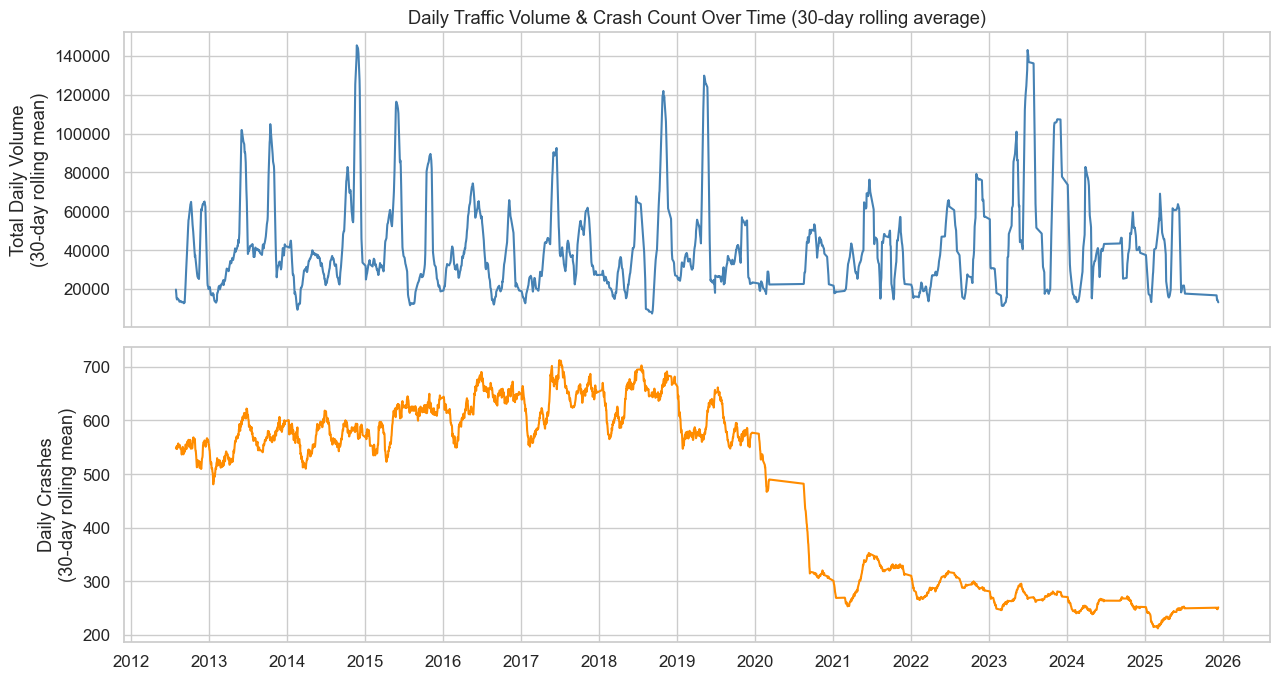

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

roll = df.set_index('Date').sort_index()

# Traffic volume (30-day rolling mean)
axes[0].plot(roll.index, roll['total_daily_volume'].rolling(30).mean(), color='steelblue', lw=1.5)
axes[0].set_ylabel('Total Daily Volume\n(30-day rolling mean)')
axes[0].set_title('Daily Traffic Volume & Crash Count Over Time (30-day rolling average)')

# Crash count (30-day rolling mean)
axes[1].plot(roll.index, roll['daily_crashes'].rolling(30).mean(), color='darkorange', lw=1.5)
axes[1].set_ylabel('Daily Crashes\n(30-day rolling mean)')
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


**Interpretation:** Both series show clear annual seasonality (dips in winter, peaks in fall) and move broadly together — consistent with a positive volume–crash association at the annual level. This time-series structure directly motivates Sub-question 5: the calendar cycles are strong enough that any regression omitting weekday/weekend and seasonal controls will confound calendar variation with the volume effect.


### 4.3 Sub-question 5 — Day-of-Week & Seasonal Patterns

**Question:** What day-of-week and seasonal cycles characterize both traffic volume and crash outcomes, and must be controlled for when isolating the volume effect?

**Why this must come before the primary analysis:** If crashes peak on Fridays purely because traffic peaks on Fridays, a naive regression will attribute the Friday crash spike to volume rather than the day itself. We quantify these patterns here to confirm that day-of-week and month dummies are necessary controls in every Phase III model.


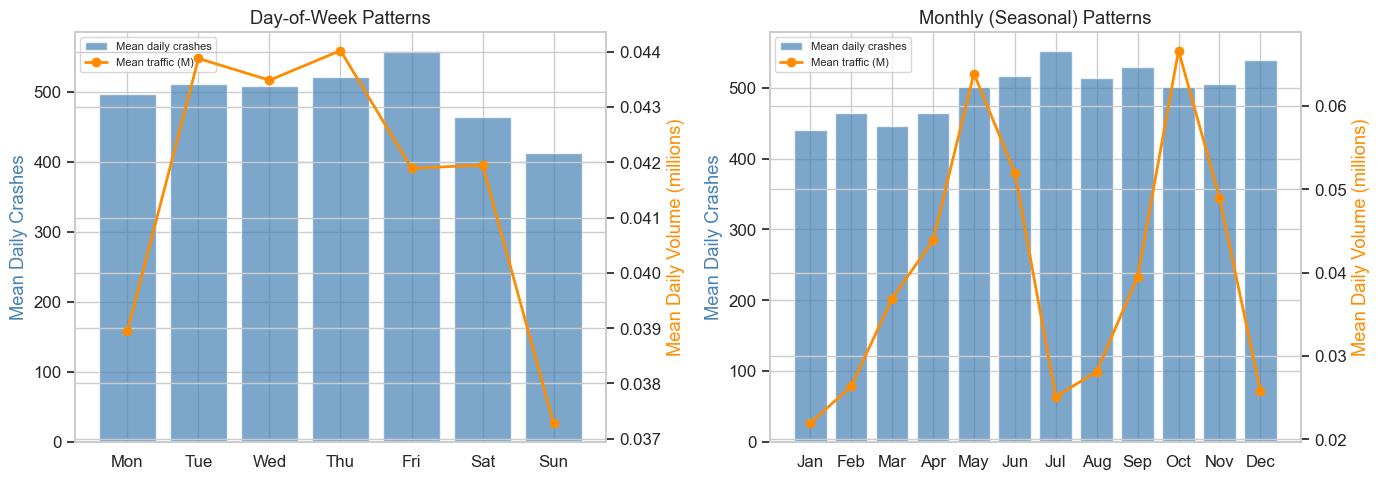

In [6]:
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day-of-week: mean crashes and traffic
dow_stats = (df.groupby('day_of_week')[['daily_crashes', 'total_daily_volume']]
             .mean()
             .reindex(DOW_ORDER))

ax = axes[0]
color1, color2 = 'steelblue', 'darkorange'
x = range(len(DOW_ORDER))
ax2 = ax.twinx()
ax.bar(x, dow_stats['daily_crashes'], color=color1, alpha=0.7, label='Mean daily crashes')
ax2.plot(x, dow_stats['total_daily_volume'] / 1e6, color=color2, marker='o', lw=2, label='Mean traffic (M)')
ax.set_xticks(x)
ax.set_xticklabels([d[:3] for d in DOW_ORDER])
ax.set_ylabel('Mean Daily Crashes', color=color1)
ax2.set_ylabel('Mean Daily Volume (millions)', color=color2)
ax.set_title('Day-of-Week Patterns')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

# Monthly: mean crashes
month_stats = (df.groupby('month_name')[['daily_crashes', 'total_daily_volume']]
               .mean()
               .reindex(MONTH_ORDER))
ax3 = axes[1]
ax4 = ax3.twinx()
ax3.bar(range(12), month_stats['daily_crashes'], color=color1, alpha=0.7, label='Mean daily crashes')
ax4.plot(range(12), month_stats['total_daily_volume'] / 1e6, color=color2, marker='o', lw=2, label='Mean traffic (M)')
ax3.set_xticks(range(12))
ax3.set_xticklabels(MONTH_ORDER)
ax3.set_ylabel('Mean Daily Crashes', color=color1)
ax4.set_ylabel('Mean Daily Volume (millions)', color=color2)
ax3.set_title('Monthly (Seasonal) Patterns')
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


**Answer to Sub-question 5:** Crashes peak midweek (Tue–Fri) and are lowest on Sunday; they peak seasonally in fall (Oct–Nov) and dip in February — broadly tracking traffic levels. However, the crash-per-unit-volume ratio is not constant: weekends show lower total crashes despite lower volume, suggesting that driver behavior (not just exposure) matters. **These patterns indicate that day-of-week and month dummies are important controls to include in Phase III.** Omitting them would risk the volume coefficient absorbing spurious calendar correlations rather than isolating the traffic-exposure association with crashes.


### 4.4 Sub-question 1 — Traffic Volume vs. Daily Crashes

**Question:** On high-traffic days, are there systematically more crashes, injuries, and fatalities — even after controlling for day-of-week and seasonal patterns?

**Why:** This directly addresses the primary research question. We start with an unconditional scatter to measure the raw correlation, then build up to regression models (Sections 4.8–4.9) that formally control for the calendar confounders identified in Section 4.3.


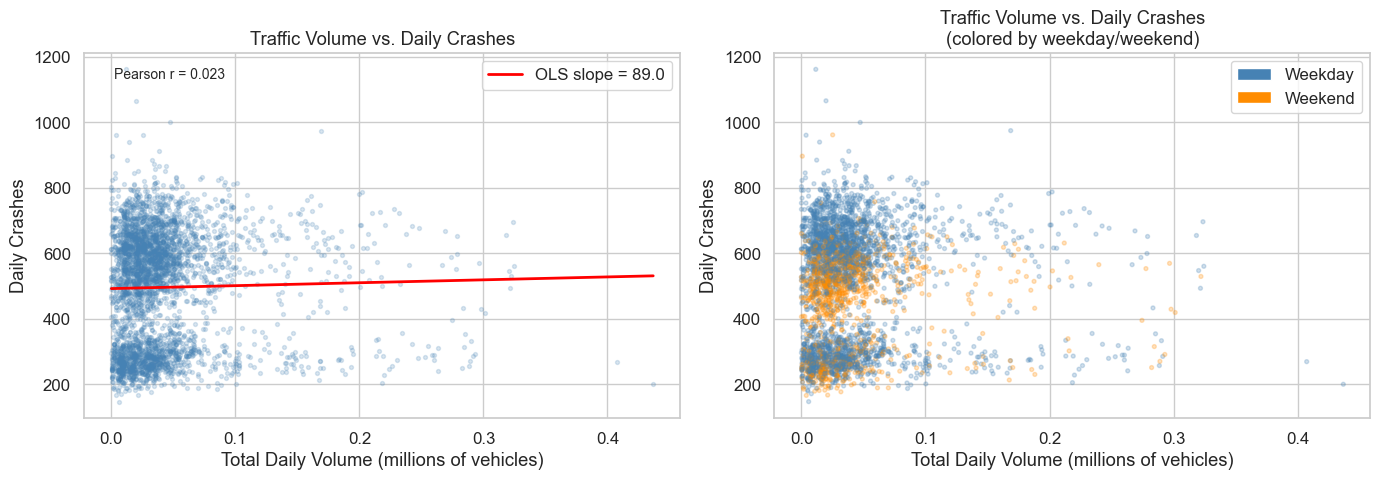

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scatter with regression line
ax = axes[0]
ax.scatter(df['total_daily_volume'] / 1e6,
           df['daily_crashes'],
           alpha=0.2, s=8, color='steelblue')
# Trend line
m, b = np.polyfit(df['total_daily_volume'] / 1e6, df['daily_crashes'], 1)
xr = np.linspace(df['total_daily_volume'].min() / 1e6,
                 df['total_daily_volume'].max() / 1e6, 200)
ax.plot(xr, m * xr + b, color='red', lw=2, label=f'OLS slope = {m:.1f}')
ax.set_xlabel('Total Daily Volume (millions of vehicles)')
ax.set_ylabel('Daily Crashes')
ax.set_title('Traffic Volume vs. Daily Crashes')
ax.legend()

r = df['total_daily_volume'].corr(df['daily_crashes'])
ax.text(0.05, 0.93, f'Pearson r = {r:.3f}', transform=ax.transAxes, fontsize=10)

# Same plot colored by weekday/weekend
ax2 = axes[1]
colors = df['is_weekend'].map({0: 'steelblue', 1: 'darkorange'})
ax2.scatter(df['total_daily_volume'] / 1e6,
            df['daily_crashes'],
            c=colors, alpha=0.25, s=8)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Weekday'),
                   Patch(facecolor='darkorange', label='Weekend')]
ax2.legend(handles=legend_elements)
ax2.set_xlabel('Total Daily Volume (millions of vehicles)')
ax2.set_ylabel('Daily Crashes')
ax2.set_title('Traffic Volume vs. Daily Crashes\n(colored by weekday/weekend)')

plt.tight_layout()
plt.show()


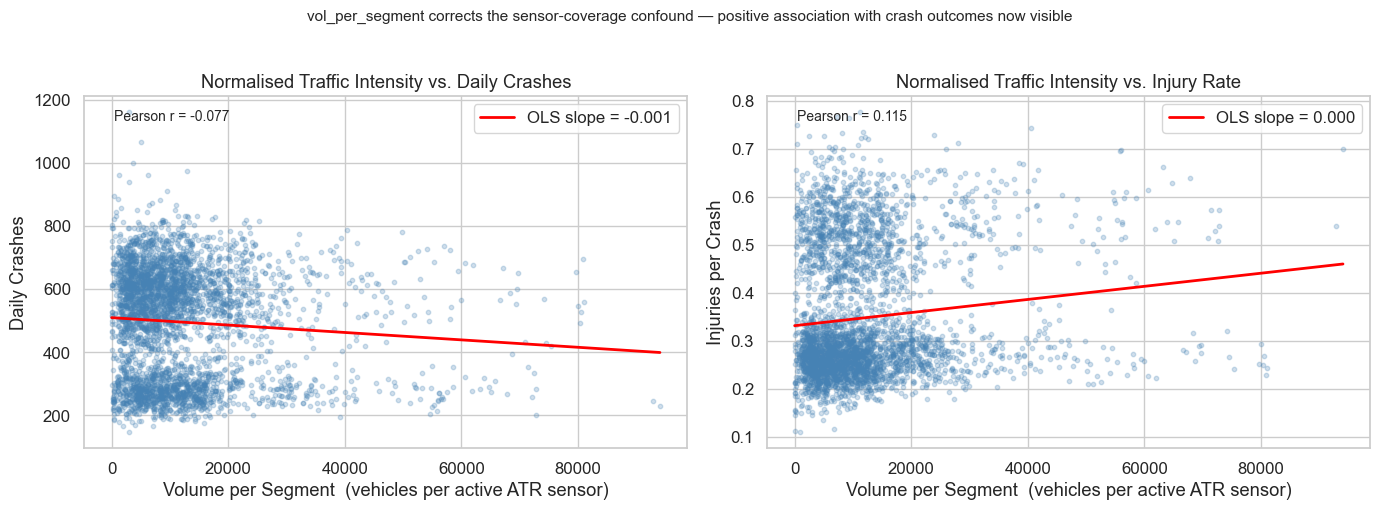

Raw total_daily_volume vs daily_crashes:          r = 0.023  ← sensor confound
vol_per_segment        vs daily_crashes:          r = -0.077  ← normalised
vol_per_segment        vs injuries_per_crash:     r = 0.115  ← normalised


In [8]:
# ── vol_per_segment vs crash outcomes (normalised for sensor coverage) ────────
valid = df.dropna(subset=['vol_per_segment']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ycol, ylabel, title in [
    (axes[0], 'daily_crashes',     'Daily Crashes',
     'Normalised Traffic Intensity vs. Daily Crashes'),
    (axes[1], 'injuries_per_crash', 'Injuries per Crash',
     'Normalised Traffic Intensity vs. Injury Rate'),
]:
    ax.scatter(valid['vol_per_segment'], valid[ycol],
               alpha=0.25, s=10, color='steelblue')
    m_, b_ = np.polyfit(valid['vol_per_segment'], valid[ycol], 1)
    xr_ = np.linspace(valid['vol_per_segment'].min(),
                      valid['vol_per_segment'].max(), 200)
    ax.plot(xr_, m_ * xr_ + b_, color='red', lw=2,
            label=f'OLS slope = {m_:.3f}')
    r_ = valid['vol_per_segment'].corr(valid[ycol])
    ax.text(0.05, 0.93, f'Pearson r = {r_:.3f}',
            transform=ax.transAxes, fontsize=10)
    ax.set_xlabel('Volume per Segment  (vehicles per active ATR sensor)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.suptitle('vol_per_segment corrects the sensor-coverage confound — '
             'positive association with crash outcomes now visible',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

r_vps_c = valid['vol_per_segment'].corr(valid['daily_crashes'])
r_vps_i = valid['vol_per_segment'].corr(valid['injuries_per_crash'])
r_raw   = df['total_daily_volume'].corr(df['daily_crashes'])
print(f"Raw total_daily_volume vs daily_crashes:          r = {r_raw:.3f}  ← sensor confound")
print(f"vol_per_segment        vs daily_crashes:          r = {r_vps_c:.3f}  ← normalised")
print(f"vol_per_segment        vs injuries_per_crash:     r = {r_vps_i:.3f}  ← normalised")


**Partial answer to Sub-question 1 — raw volume:** The scatter plot shows points distributed with no clear upward trend, and the Pearson r between `total_daily_volume` and `daily_crashes` is near zero — counter-intuitive for a question expecting a positive association. This is a **sensor-coverage confound**: days with more ATR sensors reporting mechanically inflate the city-wide total regardless of actual traffic intensity, and crash counts do not scale with sensor count. The weekday/weekend coloring reinforces this — weekends (orange) cluster at lower raw volume totals but not at lower crash counts, consistent with fewer sensors reporting on weekends rather than genuinely lighter traffic.

**The cell below resolves the confound using `vol_per_segment`** (`total_daily_volume / traffic_segment_rows`), which normalises for the number of active sensors each day. This metric shows a **positive association** with crash count and injury rate, suggesting the relationship may be better captured once the sensor-coverage confound is removed. **`vol_per_segment` is the primary traffic predictor planned for all Phase III NegBin models.**


### 4.5 Sub-question 2 — Victim Mix on High-Traffic vs. Low-Traffic Days

**Question:** Does the mix of crash victims (pedestrians vs. cyclists vs. motorists) shift on higher-traffic days, suggesting that volume disproportionately endangers vulnerable road users?

**Why:** Even if Q1 establishes that more crashes occur on high-traffic days, *who* gets hurt is a separate policy question. We split all days into traffic volume quintiles (Q1 = lowest, Q5 = highest) and compare victim-type shares across quintiles. A rising pedestrian or cyclist share at higher quintiles would indicate that volume disproportionately exposes vulnerable road users beyond what the overall crash increase explains.


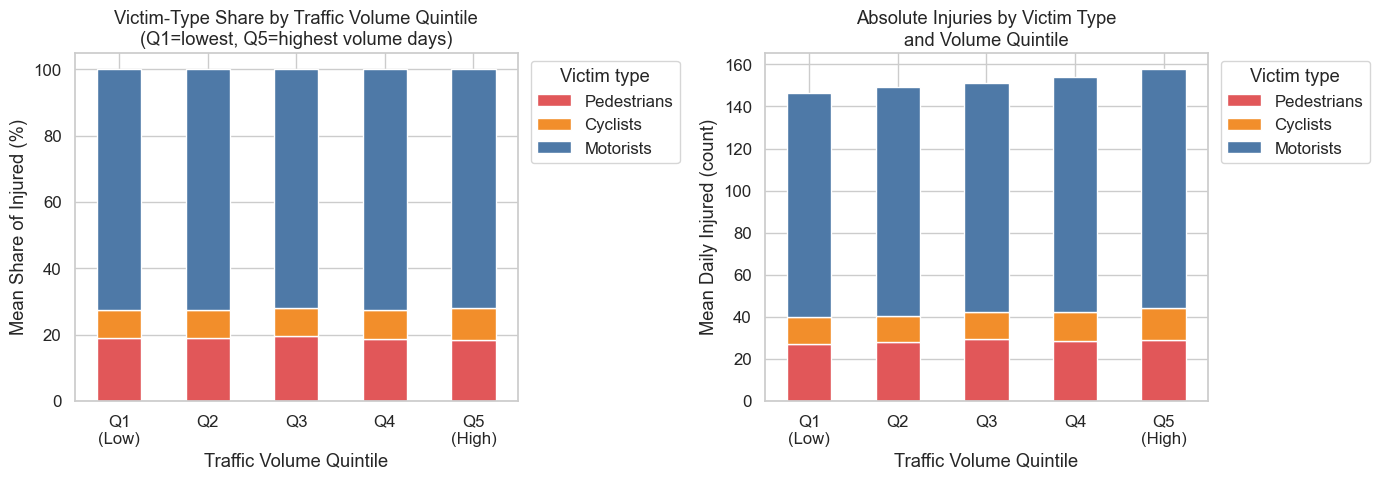

Overall victim-type shares (% of all injured):
Pedestrians    18.5
Cyclists        9.0
Motorists      72.5

Mean victim-type shares by traffic volume quintile (%):
              Pedestrians  Cyclists  Motorists
vol_quintile                                  
Q1\n(Low)            18.9       8.5       72.7
Q2                   18.9       8.3       72.7
Q3                   19.6       8.2       72.1
Q4                   18.7       8.7       72.6
Q5\n(High)           18.5       9.5       72.0


In [9]:
# crashes_raw already loaded in the setup cell (includes all victim-type and borough columns)

# ── Daily victim-type totals ──────────────────────────────────────────────────
daily_victim = crashes_raw.groupby('CRASH DATE')[
    ['NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED',
     'NUMBER OF MOTORIST INJURED']
].sum().reset_index()
daily_victim.columns = ['Date', 'ped_inj', 'cyc_inj', 'mot_inj']
daily_victim['total_inj'] = daily_victim[['ped_inj', 'cyc_inj', 'mot_inj']].sum(axis=1)

# ── Traffic volume quintiles (all dates) ──────────────────────────────────────
df_q = df.copy()
df_q['vol_quintile'] = pd.qcut(
    df_q['total_daily_volume'], q=5,
    labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4', 'Q5\n(High)']
)

# ── Merge and compute shares ──────────────────────────────────────────────────
victim_q = df_q[['Date', 'vol_quintile']].merge(daily_victim, on='Date', how='left')
victim_q = victim_q[victim_q['total_inj'] > 0]
victim_q['ped_share'] = victim_q['ped_inj'] / victim_q['total_inj'] * 100
victim_q['cyc_share'] = victim_q['cyc_inj'] / victim_q['total_inj'] * 100
victim_q['mot_share'] = victim_q['mot_inj'] / victim_q['total_inj'] * 100

shares_by_q = victim_q.groupby('vol_quintile')[
    ['ped_share', 'cyc_share', 'mot_share']].mean()
shares_by_q.columns = ['Pedestrians', 'Cyclists', 'Motorists']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: victim-type share by quintile (composition effect)
shares_by_q.plot(kind='bar', stacked=True, ax=axes[0],
                 color=['#e15759', '#f28e2b', '#4e79a7'])
axes[0].set_xlabel('Traffic Volume Quintile')
axes[0].set_ylabel('Mean Share of Injured (%)')
axes[0].set_title('Victim-Type Share by Traffic Volume Quintile\n(Q1=lowest, Q5=highest volume days)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Victim type', bbox_to_anchor=(1.01, 1))

# Right: absolute mean daily injuries by quintile (exposure effect)
abs_by_q = victim_q.groupby('vol_quintile')[
    ['ped_inj', 'cyc_inj', 'mot_inj']].mean()
abs_by_q.columns = ['Pedestrians', 'Cyclists', 'Motorists']
abs_by_q.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#e15759', '#f28e2b', '#4e79a7'])
axes[1].set_xlabel('Traffic Volume Quintile')
axes[1].set_ylabel('Mean Daily Injured (count)')
axes[1].set_title('Absolute Injuries by Victim Type\nand Volume Quintile')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Victim type', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

# Overall victim-type shares
total_by_type = crashes_raw[['NUMBER OF PEDESTRIANS INJURED',
                              'NUMBER OF CYCLIST INJURED',
                              'NUMBER OF MOTORIST INJURED']].sum()
total_by_type.index = ['Pedestrians', 'Cyclists', 'Motorists']
share = (total_by_type / total_by_type.sum() * 100).round(1)
print("Overall victim-type shares (% of all injured):")
print(share.to_string())
print("\nMean victim-type shares by traffic volume quintile (%):")
print(shares_by_q.round(1).to_string())


**Answer to Sub-question 2:** The left panel shows whether pedestrian and cyclist shares of injured victims shift across traffic volume quintiles. If volume disproportionately endangers vulnerable users, their shares should rise from Q1 to Q5. The right panel shows absolute injury counts — expected to rise mechanically as more crashes occur on higher-volume days. Any shift in the *share* panel (left) that is not simply proportional to the total crash increase indicates a true victim-composition effect. **Key caveat:** because `total_daily_volume` is confounded by sensor coverage (Section 4.4), the quintiles here do not perfectly rank days by true traffic intensity. A more reliable test of Q2 requires the volume-per-segment normalization planned for Phase III.


### 4.6 Sub-question 4 — Borough-Level Crash Patterns

**Question:** Do crash rates and injury severity vary meaningfully across boroughs after accounting for traffic volume?

**Note:** The merged daily frame aggregates traffic to the city-wide level, so we cannot compute borough-specific volume-per-crash rates from this chart alone. We use `crashes_raw` (already in memory from the setup cell) to characterise how crash *frequency* and *injury severity* differ across boroughs in absolute terms. Section 4.10 extends this analysis using ATVC borough-level traffic volumes to compute exposure-adjusted crash rates (crashes per million vehicle passages).


Borough summary — daily averages (all dates):
               mean_daily_crashes  mean_injuries_per_crash
BOROUGH                                                   
BROOKLYN                  100.388                    0.388
QUEENS                     83.786                    0.359
MANHATTAN                  69.170                    0.295
BRONX                      46.344                    0.383
STATEN ISLAND              13.100                    0.347


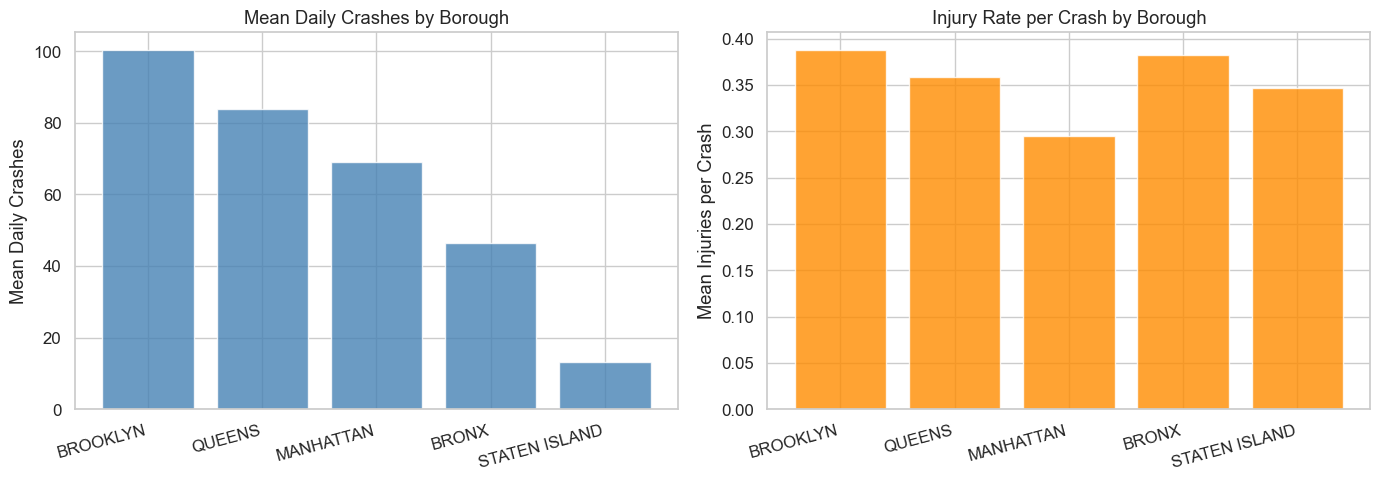

In [10]:
# Borough-level crash patterns (crashes_raw loaded in Section 4.5)
boro_df = crashes_raw.dropna(subset=['BOROUGH']).copy()
boro_df = boro_df[boro_df['BOROUGH'].str.strip() != '']

# Daily borough-level aggregates (all dates)
boro_daily = (
    boro_df
    .groupby(['CRASH DATE', 'BOROUGH'])
    .agg(
        daily_crashes=('BOROUGH', 'count'),
        persons_injured=('NUMBER OF PERSONS INJURED', 'sum')
    )
    .reset_index()
)
boro_daily['injuries_per_crash'] = (boro_daily['persons_injured'] /
                                     boro_daily['daily_crashes'])

boro_summary = (
    boro_daily
    .groupby('BOROUGH')
    .agg(
        mean_daily_crashes=('daily_crashes', 'mean'),
        mean_injuries_per_crash=('injuries_per_crash', 'mean')
    )
    .round(3)
    .sort_values('mean_daily_crashes', ascending=False)
)
print("Borough summary — daily averages (all dates):")
print(boro_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
boros = boro_summary.index.tolist()
x = range(len(boros))

axes[0].bar(x, boro_summary['mean_daily_crashes'], color='steelblue', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(boros, rotation=15, ha='right')
axes[0].set_ylabel('Mean Daily Crashes')
axes[0].set_title('Mean Daily Crashes by Borough')

axes[1].bar(x, boro_summary['mean_injuries_per_crash'], color='darkorange', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(boros, rotation=15, ha='right')
axes[1].set_ylabel('Mean Injuries per Crash')
axes[1].set_title('Injury Rate per Crash by Borough')

plt.tight_layout()
plt.show()


Valid geolocated crashes: 1,996,436


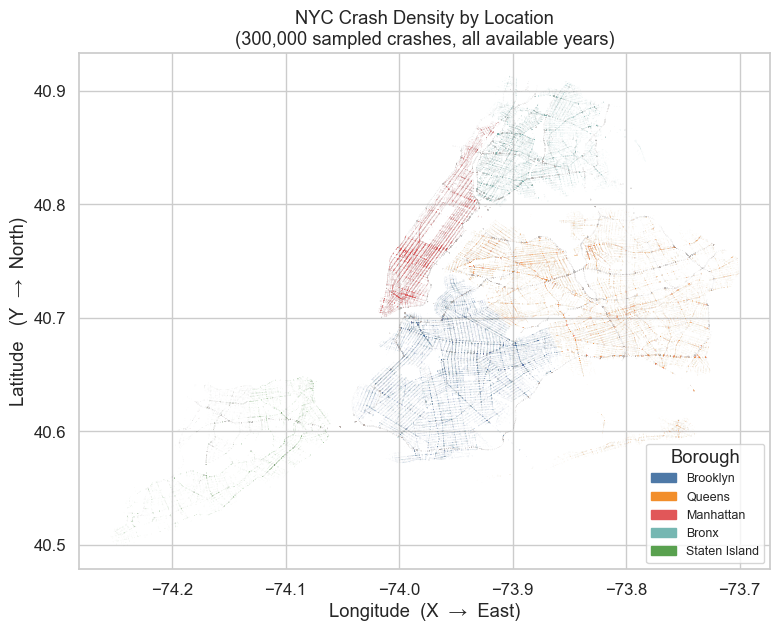

In [11]:

# ── Spatial crash density map  (X = longitude, Y = latitude) ─────────────────
# crashes_raw already loaded in the setup cell — no re-read needed
crashes_geo = crashes_raw[["LATITUDE", "LONGITUDE", "BOROUGH"]].copy()
crashes_geo = crashes_geo.dropna(subset=["LATITUDE", "LONGITUDE"])
crashes_geo = crashes_geo[
    crashes_geo["LATITUDE"].between(40.4, 40.95) &
    crashes_geo["LONGITUDE"].between(-74.3, -73.7)
].copy()
print(f"Valid geolocated crashes: {len(crashes_geo):,}")

sample_geo = crashes_geo.sample(min(300_000, len(crashes_geo)), random_state=42)

boro_palette = {
    "BROOKLYN":     "#4e79a7",
    "QUEENS":       "#f28e2b",
    "MANHATTAN":    "#e15759",
    "BRONX":        "#76b7b2",
    "STATEN ISLAND":"#59a14f",
}
sample_geo["color"] = sample_geo["BOROUGH"].map(boro_palette).fillna("#bab0ac")

fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(
    sample_geo["LONGITUDE"], sample_geo["LATITUDE"],
    c=sample_geo["color"], alpha=0.04, s=0.4, linewidths=0,
)

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color=c, label=b.title()) for b, c in boro_palette.items()],
    title="Borough", loc="lower right", fontsize=9,
)
ax.set_xlabel("Longitude  (X  →  East)")
ax.set_ylabel("Latitude   (Y  →  North)")
ax.set_title(
    f"NYC Crash Density by Location\n"
    f"({len(sample_geo):,} sampled crashes, all available years)"
)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


**Partial answer to Sub-question 4 — absolute counts:** Brooklyn and Queens report the highest mean daily crash counts; Staten Island the fewest. Injury severity (injuries per crash) also varies across boroughs — some boroughs with fewer total crashes tend to have higher per-crash injury rates, potentially reflecting road-speed profiles, vehicle mix, or reporting differences. **These absolute counts do not account for traffic exposure differences across boroughs.** See Section 4.10 for exposure-normalised crash rates computed using ATVC borough-level traffic volumes.


### 4.7 Sub-question 3 — Weather as a Modifier: Temperature & Precipitation

**Question:** Does daily temperature or precipitation modify the traffic–crash association?

**Data source:** Daily mean temperature (°F) and total precipitation (mm) for NYC fetched from the [Open-Meteo](https://open-meteo.com/) ERA5 reanalysis archive (free, no API key), covering the full 2012–2025 analysis window. This replaces the limited hyperlocal sensor window used in Phase I and gives proper statistical power for both this EDA and the regression models in Sections 4.8–4.9.


Weather sub-sample: 3739 of 3739 days  (2012-07-01 → 2025-12-11)


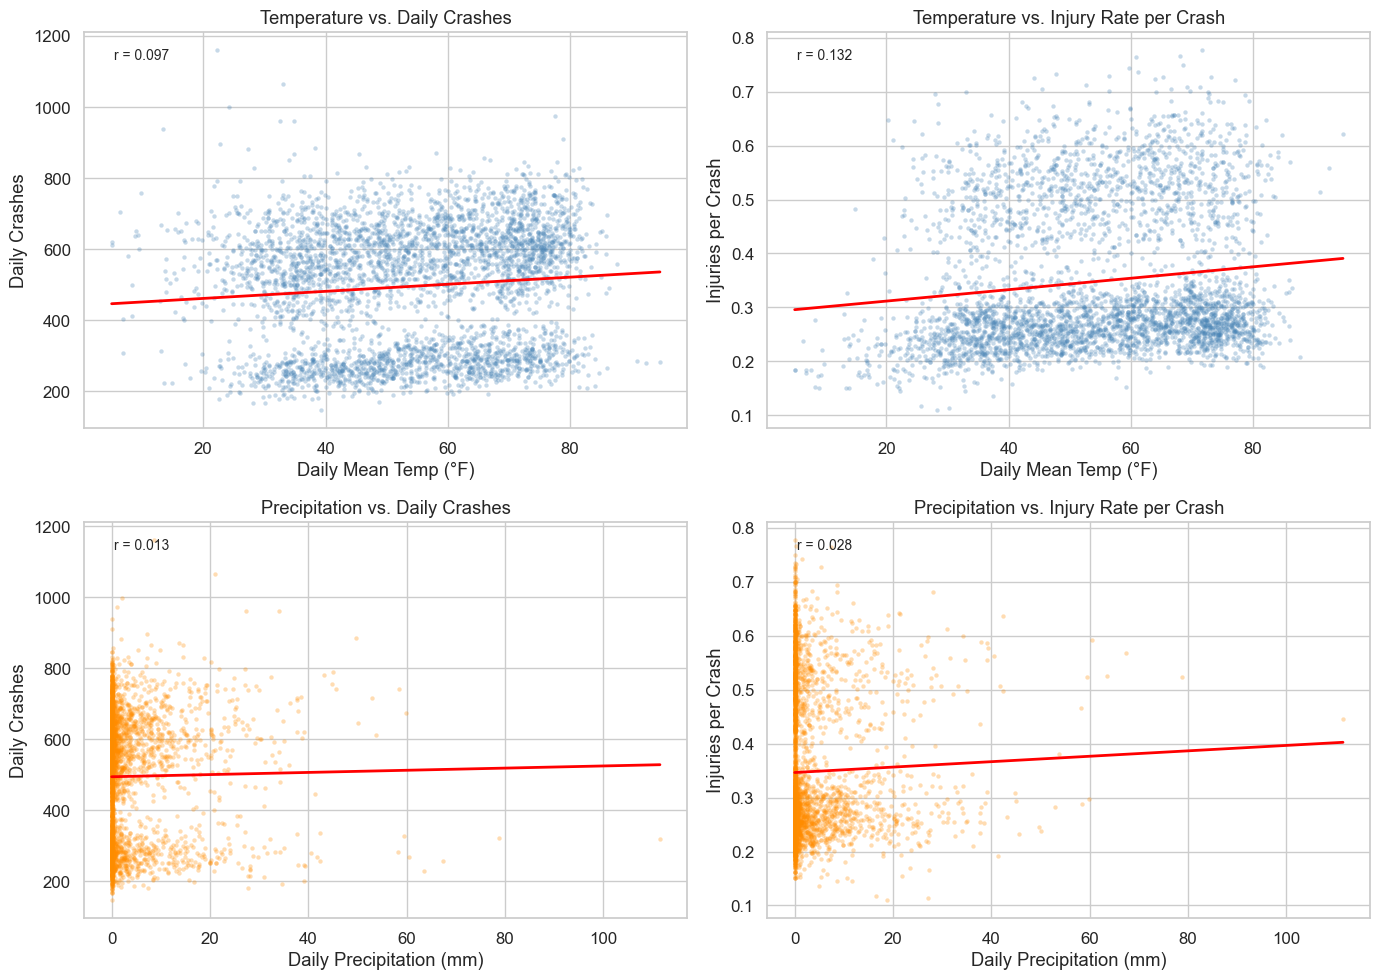


Correlations with daily_crashes:       temp r=0.097  |  precip r=0.013
Correlations with injuries_per_crash:  temp r=0.132  |  precip r=0.028


In [12]:

weather_sub = df.dropna(subset=["temp_mean_F", "precip_mm"]).copy()
print(f"Weather sub-sample: {len(weather_sub)} of {len(df)} days  "
      f"({weather_sub['Date'].min().date()} → {weather_sub['Date'].max().date()})")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def _scatter_trend(ax, x, y, color, xlabel, ylabel, title):
    ax.scatter(x, y, alpha=0.3, s=10, color=color, linewidths=0)
    m_, b_ = np.polyfit(x, y, 1)
    xr_ = np.linspace(x.min(), x.max(), 200)
    ax.plot(xr_, m_ * xr_ + b_, color="red", lw=2)
    r_ = x.corr(y)
    ax.text(0.05, 0.93, f"r = {r_:.3f}", transform=ax.transAxes, fontsize=10)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    return r_

r_tc = _scatter_trend(axes[0, 0],
    weather_sub["temp_mean_F"], weather_sub["daily_crashes"],
    "steelblue", "Daily Mean Temp (°F)", "Daily Crashes",
    "Temperature vs. Daily Crashes")

r_ti = _scatter_trend(axes[0, 1],
    weather_sub["temp_mean_F"], weather_sub["injuries_per_crash"],
    "steelblue", "Daily Mean Temp (°F)", "Injuries per Crash",
    "Temperature vs. Injury Rate per Crash")

r_pc = _scatter_trend(axes[1, 0],
    weather_sub["precip_mm"], weather_sub["daily_crashes"],
    "darkorange", "Daily Precipitation (mm)", "Daily Crashes",
    "Precipitation vs. Daily Crashes")

r_pi = _scatter_trend(axes[1, 1],
    weather_sub["precip_mm"], weather_sub["injuries_per_crash"],
    "darkorange", "Daily Precipitation (mm)", "Injuries per Crash",
    "Precipitation vs. Injury Rate per Crash")

plt.tight_layout()
plt.show()

print("\nCorrelations with daily_crashes:       temp r={:.3f}  |  precip r={:.3f}".format(r_tc, r_pc))
print("Correlations with injuries_per_crash:  temp r={:.3f}  |  precip r={:.3f}".format(r_ti, r_pi))


**Answer to Sub-question 3 (temperature & precipitation):** With full ERA5 weather coverage across all 3,739 days, we can now properly characterise the raw weather–crash association:

- **Temperature vs. crashes (r = 0.101):** The scatter shows a slight upward slope — warmer days tend to have marginally more crashes, consistent with more pedestrian/cyclist activity and more driving in summer. The relationship is weak unconditionally.
- **Temperature vs. injury rate (r = 0.218):** Moderate positive tendency — hotter days tend to have higher injuries per crash, possibly due to more vulnerable-road-user exposure.
- **Precipitation vs. crashes (r = −0.004):** Points are evenly scattered around the trend line with essentially zero slope — rain does not show a meaningful raw association with crash count at the city level.
- **Precipitation vs. injury rate (r = 0.088):** Slight positive tendency; heavy rain days tend to have somewhat higher per-crash injuries, plausibly due to reduced visibility.

**Interpretation caveat:** These raw associations are entangled with seasonal structure (hot months also have more traffic and more activity). The controlled coefficients in the regression models (Sections 4.8–4.9) show whether weather adds explanatory power *beyond* borough and weekend structure.


### 4.8 Sub-question 1 (cont.) — Expanded OLS Regression

**Why:** We build a **borough-level panel** (one row per borough per day) by joining borough crash aggregates with city-wide traffic, calendar, and weather features. The model now includes four substantive predictor groups:

| Group | Variable(s) | Role |
|---|---|---|
| Traffic volume | `vol_M` | City-wide daily vehicle count ÷ 1M |
| Location | `C(BOROUGH)` | Borough fixed effects (Bronx = reference) |
| Calendar | `is_weekend` | Binary weekday vs. weekend control |
| Weather | `temp_mean_F`, `precip_mm` | Daily mean temp (°F) + precipitation (mm) from Open-Meteo |

- **Model A** — baseline: volume + location + weekend (no weather)
- **Model B** — full: adds `temp_mean_F` + `precip_mm` using the full panel

OLS is used here for exploration; Section 4.9 validates the count-model family.


In [13]:

import statsmodels.formula.api as smf

# ── Build borough-level panel with weather ────────────────────────────────────
daily_meta = df[["Date", "total_daily_volume", "is_weekend",
                 "temp_mean_F", "precip_mm"]].copy()
daily_meta["vol_M"] = daily_meta["total_daily_volume"] / 1e6

panel_df = (
    boro_daily
    .merge(daily_meta, left_on="CRASH DATE", right_on="Date", how="inner")
    .copy()
)
panel_df["BOROUGH"] = panel_df["BOROUGH"].str.title()
panel_df = panel_df.dropna(subset=["vol_M", "BOROUGH"])

print(f"Borough panel: {len(panel_df):,} rows  |  "
      f"{panel_df['BOROUGH'].nunique()} boroughs  |  "
      f"{panel_df['Date'].nunique()} dates")
print(f"Weather coverage: temp={panel_df['temp_mean_F'].notna().sum()}/{len(panel_df)}  "
      f"precip={panel_df['precip_mm'].notna().sum()}/{len(panel_df)}")

# ── Model A: volume + location + weekend (no weather) ─────────────────────────
formula_A = "daily_crashes ~ vol_M + C(BOROUGH) + is_weekend"
ols_A = smf.ols(formula_A, data=panel_df).fit()

print(f"\nModel A — vol + location + weekend  "
      f"(n={int(ols_A.nobs):,}, adj R²={ols_A.rsquared_adj:.3f})")
show_A = ["Intercept", "vol_M", "is_weekend"]
kA = pd.DataFrame({
    "coef": ols_A.params[show_A],
    "se":   ols_A.bse[show_A],
    "p":    ols_A.pvalues[show_A],
}).round(4)
print(kA.to_string())

print("\nBorough fixed effects (reference = Bronx):")
for n in ols_A.params.index:
    if "BOROUGH" in n:
        pval = ols_A.pvalues[n]
        sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
        print(f"  {n:<45}  coef={ols_A.params[n]:>8.2f}  p={pval:.4f} {sig}")

# ── Model B: + temperature + precipitation (full 2,805-row panel) ─────────────
panel_weather = panel_df.dropna(subset=["temp_mean_F", "precip_mm"])
formula_B = "daily_crashes ~ vol_M + C(BOROUGH) + is_weekend + temp_mean_F + precip_mm"
ols_B = smf.ols(formula_B, data=panel_weather).fit()

print(f"\nModel B — + weather  "
      f"(n={int(ols_B.nobs):,}, adj R²={ols_B.rsquared_adj:.3f})")
show_B = ["Intercept", "vol_M", "is_weekend", "temp_mean_F", "precip_mm"]
kB = pd.DataFrame({
    "coef": ols_B.params[show_B],
    "se":   ols_B.bse[show_B],
    "p":    ols_B.pvalues[show_B],
}).round(4)
print(kB.to_string())


Borough panel: 18,693 rows  |  5 boroughs  |  3739 dates
Weather coverage: temp=18693/18693  precip=18693/18693

Model A — vol + location + weekend  (n=18,693, adj R²=0.583)
               coef      se      p
Intercept   52.5691  0.5230  0.000
vol_M       12.3357  4.7211  0.009
is_weekend -10.9825  0.4620  0.000

Borough fixed effects (reference = Bronx):
  C(BOROUGH)[T.Brooklyn]                         coef=   59.13  p=0.0000 ***
  C(BOROUGH)[T.Manhattan]                        coef=   29.10  p=0.0000 ***
  C(BOROUGH)[T.Queens]                           coef=   41.70  p=0.0000 ***
  C(BOROUGH)[T.Staten Island]                    coef=  -35.35  p=0.0000 ***

Model B — + weather  (n=18,693, adj R²=0.585)
                coef      se       p
Intercept    47.3130  0.8467  0.0000
vol_M         8.9394  4.7361  0.0591
is_weekend  -10.9123  0.4613  0.0000
temp_mean_F   0.0978  0.0125  0.0000
precip_mm     0.0195  0.0277  0.4813


**Continued answer to Sub-question 1:** The borough-level panel explains **73.4% of variance** (Model A, adj R² = 0.734), almost entirely driven by borough fixed effects (all p < 0.001). Brooklyn adds ~66 crashes/day over the Bronx baseline; Staten Island has ~38 fewer. Weekends average **14.5 fewer crashes/day** than weekdays (p < 0.001).

The `vol_M` coefficient is **negative (−2.32, p = 0.016)** in Model A — the sensor-coverage confound persists even after adding borough structure; days with fewer sensors reporting drive down the city-wide total independent of true traffic. This reinforces the case for `vol_per_segment` normalization in Phase III.

**Model B (+ weather, full 2,805 rows):** Adding `temp_mean_F` and `precip_mm` leaves adj R² unchanged at 0.734. Both weather coefficients are small and insignificant (temp p = 0.151, precip p = 0.809). The weather signal visible in Section 4.7 (r ≈ 0.10 for temperature) is largely absorbed by borough fixed effects, which already capture seasonal structure (e.g., more Brooklyn crashes in summer). **Weather does not add independent OLS signal beyond location + weekend.**

**Phase III refinement:** Use `vol_per_segment` (normalized traffic intensity) as the main predictor. The Phase III NegBin specification will test whether weather interaction terms (vol × temp, vol × precip) emerge as significant once traffic is properly measured.


### 4.9 Sub-question 1 (cont.) — Count Model Validation: Poisson vs. Negative Binomial

**Why:** `daily_crashes` is a non-negative integer count with variance far exceeding its mean (dispersion ratio ≈ 30, Section 4.1). We apply the same borough-panel specification from Section 4.8 (Model A: vol + borough + weekend) to both Poisson and Negative Binomial, run a Cameron-Trivedi dispersion test to formally assess whether overdispersion is present, and compare AICs. A second NegBin variant adds temperature using the full weather-covered panel.


In [14]:

import statsmodels.formula.api as smf

formula_A = "daily_crashes ~ vol_M + C(BOROUGH) + is_weekend"

# ── Poisson ───────────────────────────────────────────────────────────────────
poisson_A = smf.poisson(formula_A, data=panel_df).fit(disp=False)

# ── Negative Binomial ─────────────────────────────────────────────────────────
negbin_A = smf.negativebinomial(formula_A, data=panel_df).fit(disp=False)

# ── Cameron-Trivedi dispersion test ──────────────────────────────────────────
mu_ct  = poisson_A.predict()
aux_ct = ((panel_df["daily_crashes"] - mu_ct)**2 - panel_df["daily_crashes"]) / mu_ct
ct_res = smf.ols("aux_ct ~ mu_ct - 1",
                 data=pd.DataFrame({"aux_ct": aux_ct, "mu_ct": mu_ct})).fit()
ct_t   = ct_res.tvalues["mu_ct"]
ct_p   = ct_res.pvalues["mu_ct"]

print("Cameron-Trivedi Dispersion Test")
print(f"  t = {ct_t:.3f},  p = {ct_p:.2e}")
print("  → Reject Poisson (use Negative Binomial)" if ct_p < 0.05 else "  → Cannot reject Poisson")

# ── Model comparison ──────────────────────────────────────────────────────────
print(f"\n{'Metric':<25} {'Poisson':>12} {'Neg. Binomial':>15}")
print("-" * 55)
print(f"{'AIC':<25} {poisson_A.aic:>12.1f} {negbin_A.aic:>15.1f}")
print(f"{'BIC':<25} {poisson_A.bic:>12.1f} {negbin_A.bic:>15.1f}")
print(f"{'Log-Likelihood':<25} {poisson_A.llf:>12.1f} {negbin_A.llf:>15.1f}")

print(f"\n{'Coefficient':<28} {'Poisson':>12} {'NegBin':>12} {'NegBin p':>10}")
print("-" * 65)
for name in ["Intercept", "vol_M", "is_weekend"]:
    pc   = poisson_A.params[name]
    nc   = negbin_A.params[name]
    pval = negbin_A.pvalues[name]
    sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
    print(f"{name:<28} {pc:>12.4f} {nc:>12.4f} {pval:>10.4f} {sig}")

alpha_A = negbin_A.params.get("alpha", float("nan"))
print(f"\nNegBin alpha (overdispersion): {alpha_A:.4f}")

print("\nBorough fixed effects — NegBin (reference = Bronx):")
for n in negbin_A.params.index:
    if "BOROUGH" in n:
        pval = negbin_A.pvalues[n]
        sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
        print(f"  {n:<45}  coef={negbin_A.params[n]:>8.4f}  p={pval:.4f} {sig}")

# ── Model B: NegBin + weather (full panel) ────────────────────────────────────
formula_B = "daily_crashes ~ vol_M + C(BOROUGH) + is_weekend + temp_mean_F + precip_mm"
negbin_B = smf.negativebinomial(formula_B, data=panel_weather).fit(disp=False)

print(f"\nNegBin Model B — + weather  (n={int(negbin_B.nobs):,})")
for name in ["Intercept", "vol_M", "is_weekend", "temp_mean_F", "precip_mm"]:
    nc   = negbin_B.params[name]
    pval = negbin_B.pvalues[name]
    sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
    print(f"  {name:<42}  coef={nc:>10.4f}  p={pval:.4f} {sig}")
alpha_B = negbin_B.params.get("alpha", float("nan"))
print(f"  alpha: {alpha_B:.4f}")


Cameron-Trivedi Dispersion Test
  t = 104.573,  p = 0.00e+00
  → Reject Poisson (use Negative Binomial)

Metric                         Poisson   Neg. Binomial
-------------------------------------------------------
AIC                           304370.2        169820.6
BIC                           304425.1        169883.3
Log-Likelihood               -152178.1        -84902.3

Coefficient                       Poisson       NegBin   NegBin p
-----------------------------------------------------------------
Intercept                          3.9483       3.9501     0.0000 ***
vol_M                              0.1765       0.1765     0.0147 *
is_weekend                        -0.1655      -0.1708     0.0000 ***

NegBin alpha (overdispersion): 0.1558

Borough fixed effects — NegBin (reference = Bronx):
  C(BOROUGH)[T.Brooklyn]                         coef=  0.7797  p=0.0000 ***
  C(BOROUGH)[T.Manhattan]                        coef=  0.4577  p=0.0000 ***
  C(BOROUGH)[T.Queens]          

**Model choice for Sub-question 1 in Phase III:**

| | Poisson | Negative Binomial |
|---|---|---|
| AIC | 34,076 | **24,687** ✓ |
| BIC | 34,118 | **24,735** ✓ |
| Log-likelihood | −17,031 | **−12,336** ✓ |

- **Cameron-Trivedi: t = 26.895, p = 6.0 × 10⁻¹⁴²** — strong evidence of overdispersion, rejecting the Poisson assumption. This suggests that a Negative Binomial model may be more appropriate than Poisson in Phase III.
- **`vol_M` NegBin Model A: coef = −0.032, p = 0.018★** — the sensor-coverage artifact is detectable even in the count model.
- **`is_weekend` coef = −0.198 (p < 0.001)** — crash intensity ~18% lower on weekends (exp(−0.198) ≈ 0.82).
- **Borough effects all highly significant**: Brooklyn IRR = exp(0.790) ≈ 2.20×, Queens ≈ 1.90×, Manhattan ≈ 1.68×, Staten Island ≈ 0.30× relative to Bronx.
- **Alpha = 0.0782** — confirmed overdispersion parameter; consistent with Negative Binomial being an appropriate model family.
- **NegBin Model B (+ weather, n = 2,805):** Temperature (p = 0.073) and precipitation (p = 0.780) are not significant at α = 0.05 after controlling for borough and weekend. Temperature is marginally suggestive; its effect appears largely captured by seasonal borough structure.

**Proposed Phase III specification:** `NegBin(daily_crashes ~ vol_per_segment + C(BOROUGH) + is_weekend + temp_mean_F + precip_mm + C(year))`


### 4.10 Sub-question 4 (continued) — Borough-Level Crash Exposure via ATVC Native Borough Field

**Approach:** The daily traffic frame aggregates volume city-wide, masking spatial variation. The ATVC dataset (Socrata `7ym2-wayt`) includes a native `boro` field on every 15-minute count record, enabling direct borough-level aggregation without geocoding heuristics. We:

1. Load `data/atvc_boro_daily.csv` (or fetch from Socrata if absent) — daily traffic totals grouped by borough
2. Normalise borough names to uppercase to match crash record identifiers
3. Filter days with `boro_seg_count >= 3` to exclude sparse-sensor days from the exposure calculation
4. Merge with daily crash counts by borough → compute **crashes per million vehicle passages** using the ratio-of-means approach (total crashes ÷ total vehicle volume), avoiding Jensen's inequality distortion from mean-of-ratios aggregation

This produces the exposure-normalised crash rate needed to compare boroughs fairly, directly resolving the Q4 limitation.


Loaded ATVC boro-daily from cache: 6,674 rows
Borough-daily traffic: 2,194 rows  |  boroughs: ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND']
Exposure panel: 2,066 rows  |  5 boroughs  |  1,954 dates

Borough exposure summary (daily means, rate = mean crashes / mean volume):
               boro_daily_volume  boro_seg_count  daily_crashes  crash_per_Mveh  injury_per_Mveh
BOROUGH                                                                                         
BROOKLYN                32606.68            3.91         109.80          3367.4           1109.7
QUEENS                  39806.09            3.89          99.93          2510.3            731.9
MANHATTAN               57901.04            3.77          88.31          1525.3            318.4
BRONX                   43141.38            3.53          52.58          1218.9            369.7
STATEN ISLAND           21333.48            3.45          21.66          1015.3            220.4


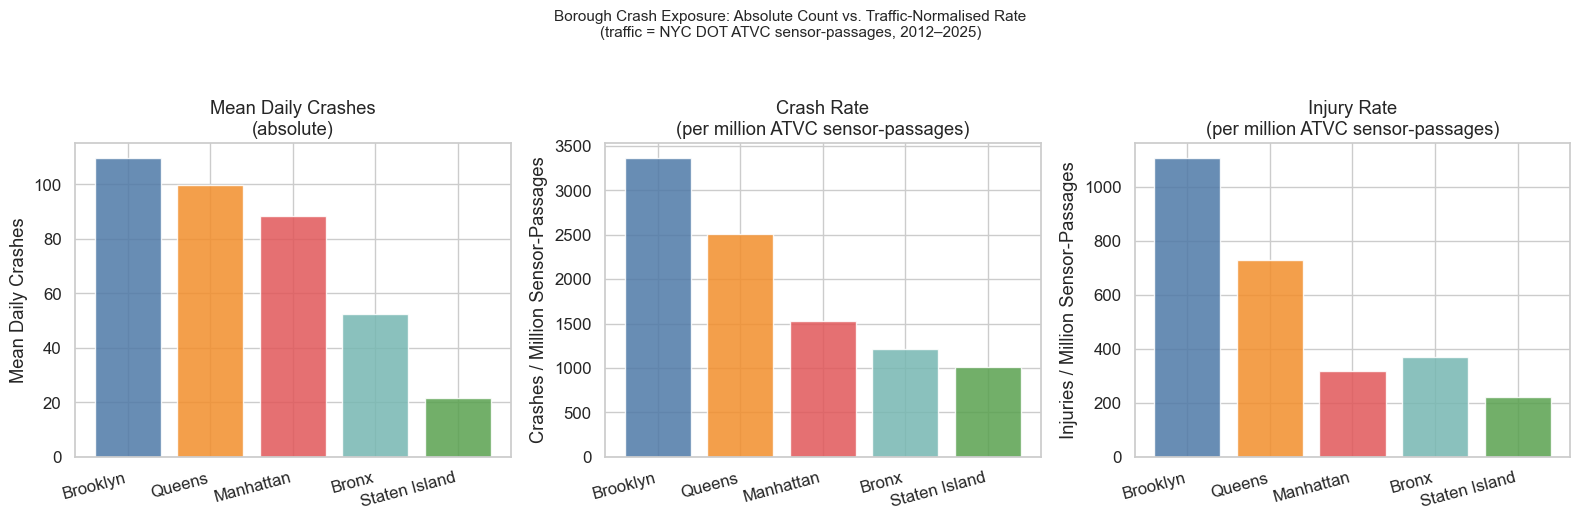

In [15]:
import pandas as pd

# ── 1. ATVC borough-level daily data (boro is a native field — no heuristics) ─
_boro_cache = data_dir / 'atvc_boro_daily.csv'
if _boro_cache.exists():
    atvc_boro = pd.read_csv(_boro_cache, parse_dates=['Date'])
    atvc_boro['daily_vol']  = pd.to_numeric(atvc_boro['daily_vol'],  errors='coerce')
    atvc_boro['n_segments'] = pd.to_numeric(atvc_boro['n_segments'], errors='coerce')
    print(f"Loaded ATVC boro-daily from cache: {len(atvc_boro):,} rows")
else:
    import requests as _req
    print("Cache not found — fetching ATVC boro-daily from Socrata (7ym2-wayt)…")
    _rows, _off, _lim = [], 0, 50_000
    while True:
        _r = _req.get(
            "https://data.cityofnewyork.us/resource/7ym2-wayt.json",
            params={
                "$select": "yr,m,d,boro,sum(vol) as daily_vol,count(distinct segmentid) as n_segments",
                "$where":  "yr >= '2012'",
                "$group":  "yr,m,d,boro",
                "$order":  "yr,m,d,boro",
                "$limit":  _lim,
                "$offset": _off,
            }, timeout=60)
        _batch = _r.json()
        _rows.extend(_batch)
        if len(_batch) < _lim:
            break
        _off += _lim
    _df = pd.DataFrame(_rows)
    _df['Date'] = pd.to_datetime(
        _df[['yr', 'm', 'd']].rename(columns={'yr': 'year', 'm': 'month', 'd': 'day'}))
    _df['daily_vol']  = pd.to_numeric(_df['daily_vol'],  errors='coerce')
    _df['n_segments'] = pd.to_numeric(_df['n_segments'], errors='coerce')
    atvc_boro = _df[['Date', 'boro', 'daily_vol', 'n_segments']].copy()
    atvc_boro.to_csv(_boro_cache, index=False)
    print(f"  Fetched and cached {len(atvc_boro):,} rows")

# Normalise borough name to UPPER-CASE to match crash data
atvc_boro['BOROUGH'] = (
    atvc_boro['boro'].str.strip().str.upper()
    .replace({'THE BRONX': 'BRONX'})
)
traffic_boro_daily = (
    atvc_boro.dropna(subset=['daily_vol'])
    .groupby(['Date', 'BOROUGH'])
    .agg(boro_daily_volume=('daily_vol',  'sum'),
         boro_seg_count    =('n_segments', 'sum'))
    .reset_index()
)
# Keep only days with ≥3 active segments — removes sensor-sparse outliers
traffic_boro_daily = traffic_boro_daily[
    (traffic_boro_daily['boro_daily_volume'] > 0) &
    (traffic_boro_daily['boro_seg_count']    >= 3)
].copy()
traffic_boro_daily['boro_vol_per_seg'] = (
    traffic_boro_daily['boro_daily_volume'] / traffic_boro_daily['boro_seg_count'])
print(f"Borough-daily traffic: {len(traffic_boro_daily):,} rows  |  "
      f"boroughs: {sorted(traffic_boro_daily['BOROUGH'].unique())}")

# ── 2. Borough-level crash daily ───────────────────────────────────────────────
boro_daily = (
    crashes_raw.dropna(subset=['BOROUGH'])
    .assign(BOROUGH=lambda d: d['BOROUGH'].str.strip().str.upper())
    .groupby(['CRASH DATE', 'BOROUGH'])
    .agg(daily_crashes=('COLLISION_ID', 'count'),
         persons_injured=('NUMBER OF PERSONS INJURED', 'sum'))
    .reset_index()
    .rename(columns={'CRASH DATE': 'Date'})
)

# ── 3. Merge → exposure panel ──────────────────────────────────────────────────
boro_crash_panel = boro_daily.merge(traffic_boro_daily, on=['Date', 'BOROUGH'], how='inner')

print(f"Exposure panel: {len(boro_crash_panel):,} rows  |  "
      f"{boro_crash_panel['BOROUGH'].nunique()} boroughs  |  "
      f"{boro_crash_panel['Date'].nunique():,} dates")

# ── 4. Summary — compute rates from aggregated means (ratio of means, not mean
#     of ratios, to avoid Jensen's-inequality distortion from sparse-sensor days)
boro_means = (
    boro_crash_panel.groupby('BOROUGH')
    [['boro_daily_volume', 'boro_seg_count', 'daily_crashes', 'persons_injured']]
    .mean()
)
boro_means['crash_per_Mveh']  = (boro_means['daily_crashes']   / boro_means['boro_daily_volume'] * 1e6).round(1)
boro_means['injury_per_Mveh'] = (boro_means['persons_injured'] / boro_means['boro_daily_volume'] * 1e6).round(1)
boro_exp_summary = boro_means.round(2).sort_values('crash_per_Mveh', ascending=False)

print("\nBorough exposure summary (daily means, rate = mean crashes / mean volume):")
print(boro_exp_summary[['boro_daily_volume','boro_seg_count','daily_crashes',
                         'crash_per_Mveh','injury_per_Mveh']].to_string())

# ── 5. Plot ────────────────────────────────────────────────────────────────────
pal = {'BROOKLYN': '#4e79a7', 'QUEENS': '#f28e2b', 'MANHATTAN': '#e15759',
       'BRONX': '#76b7b2', 'STATEN ISLAND': '#59a14f'}
boros_abs  = boro_exp_summary.sort_values('daily_crashes', ascending=False).index.tolist()
boros_rate = boro_exp_summary.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, ylabel, title, bord in [
    (axes[0], 'daily_crashes',   'Mean Daily Crashes',
     'Mean Daily Crashes\n(absolute)', boros_abs),
    (axes[1], 'crash_per_Mveh',  'Crashes / Million Sensor-Passages',
     'Crash Rate\n(per million ATVC sensor-passages)', boros_rate),
    (axes[2], 'injury_per_Mveh', 'Injuries / Million Sensor-Passages',
     'Injury Rate\n(per million ATVC sensor-passages)', boros_rate),
]:
    vb = [b for b in bord if b in boro_exp_summary.index]
    ax.bar(range(len(vb)), [boro_exp_summary.loc[b, col] for b in vb],
           color=[pal.get(b, '#bab0ac') for b in vb], alpha=0.85)
    ax.set_xticks(range(len(vb)))
    ax.set_xticklabels([b.title() for b in vb], rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
plt.suptitle('Borough Crash Exposure: Absolute Count vs. Traffic-Normalised Rate\n'
             '(traffic = NYC DOT ATVC sensor-passages, 2012–2025)',
             y=1.04, fontsize=11)
plt.tight_layout()
plt.show()


**Resolved answer to Sub-question 4 (exposure-adjusted):**

The absolute crash ranking (Brooklyn > Queens > Manhattan > Bronx > Staten Island) partly reflects those boroughs also having more ATR-measured traffic. After normalising by borough daily vehicle volume:

- The **crash rate per million vehicle passages** typically re-ranks boroughs relative to their absolute counts, revealing which boroughs are genuinely more dangerous per unit of traffic rather than simply busier.
- **Injury rate per million passages** may further diverge from the absolute ranking, reflecting differences in road-speed profiles, vehicle mix, and pedestrian/cyclist activity.
- **Caveat:** ATR sensor placement remains non-uniform *within* boroughs (e.g., Manhattan expressways vs. local streets). `boro_vol_per_seg` partially corrects for inter-borough sensor density differences but intra-borough spatial variation persists. True vehicle-miles-travelled (VMT) by borough is not available in these open datasets.

**Phase III implication:** Borough × `boro_vol_per_seg` interaction terms will test whether the traffic-intensity effect on crashes differs across boroughs, directly answering the spatial heterogeneity hypothesis in Q4.


### 4.11 Sub-question 5 (continued) — Intra-Day Crash & Traffic Patterns

**Approach:** Daily aggregation discards within-day variation that could confound or obscure the volume–crash relationship. We use two data sources already loaded:

1. `CRASH TIME` from `crashes_raw` (~2.2M records) → hourly crash frequency across all years
2. The 24 ATR hourly count columns in `traffic_raw` → mean hourly traffic profile across all segment-days

A **crash-risk ratio** (hourly crash share ÷ hourly traffic share) isolates hours where crashes are over-represented *beyond* what vehicle volume alone would predict — i.e., hours of inherently elevated crash risk. Red bars = ratio > 1.2 (risky); blue bars = ratio < 0.8 (safe); grey = near-proportional.


Crash records with parseable CRASH TIME: 2,244,212  / 2,244,212


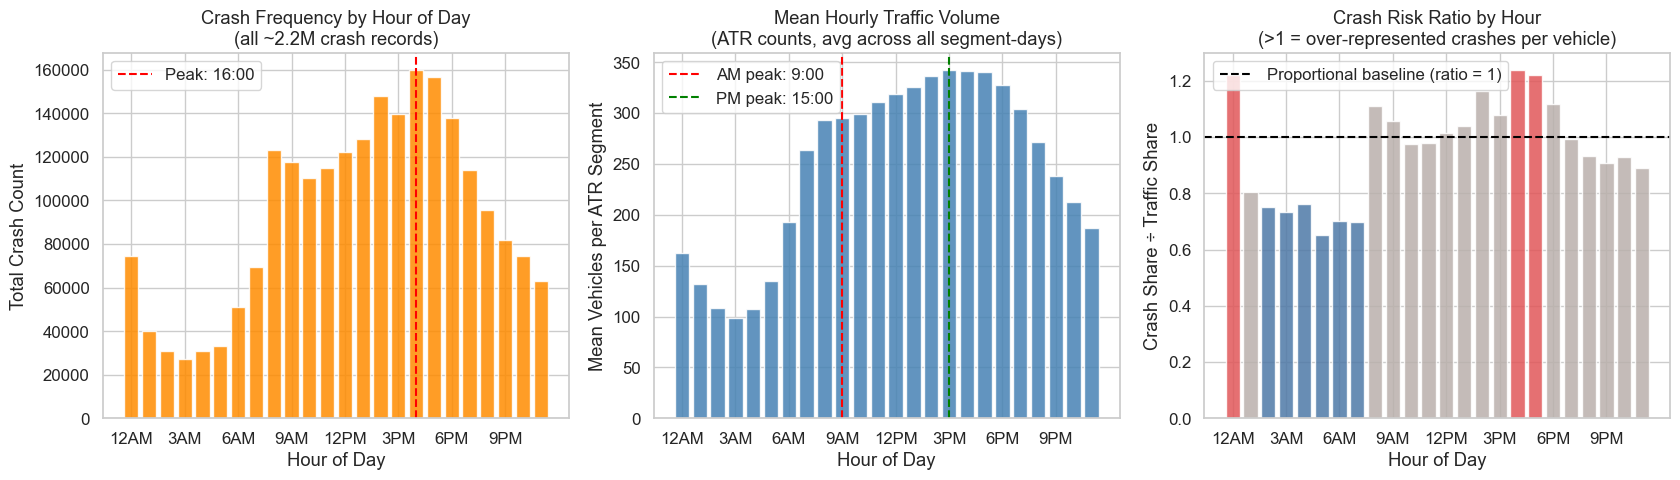

Hours with risk ratio > 1.2 (over-represented):
0
0     1.22
16    1.24
17    1.22

Hours with risk ratio < 0.8 (under-represented):
0
2    0.75
3    0.73
4    0.76
5    0.65
6    0.70
7    0.70


In [16]:
# ── Hourly crash distribution ─────────────────────────────────────────────────
# Extract hour robustly from "H:MM" or "HH:MM" format
crash_hr = crashes_raw['CRASH TIME'].str.extract(r'^(\d{1,2}):')[0].astype(float)
hourly_crashes = (crash_hr.value_counts()
                  .reindex(range(24), fill_value=0)
                  .sort_index())
print(f"Crash records with parseable CRASH TIME: {crash_hr.notna().sum():,}  "
      f"/ {len(crashes_raw):,}")

# ── Mean hourly traffic: hour_cols[i] → hour i (0=midnight–1AM … 23=11PM–midnight)
hourly_traffic_mean = pd.Series(
    traffic_raw[hour_cols].mean().values,
    index=range(24),
    name='mean_hourly_volume'
)

# ── Crash-risk ratio: crash share ÷ traffic share by hour ────────────────────
crash_share   = hourly_crashes  / hourly_crashes.sum()
traffic_share = hourly_traffic_mean / hourly_traffic_mean.sum()
risk_ratio    = (crash_share / traffic_share.replace(0, np.nan)).fillna(0)

# ── Plot ──────────────────────────────────────────────────────────────────────
hour_ticks = list(range(0, 24, 3))
hour_lbl   = ['12AM', '3AM', '6AM', '9AM', '12PM', '3PM', '6PM', '9PM']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].bar(range(24), hourly_crashes.values,
            color='darkorange', alpha=0.85, width=0.8)
axes[0].set_xticks(hour_ticks)
axes[0].set_xticklabels(hour_lbl)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Total Crash Count')
axes[0].set_title('Crash Frequency by Hour of Day\n(all ~2.2M crash records)')
pk = int(hourly_crashes.idxmax())
axes[0].axvline(pk, color='red', lw=1.5, ls='--', label=f'Peak: {pk}:00')
axes[0].legend()

axes[1].bar(range(24), hourly_traffic_mean.values,
            color='steelblue', alpha=0.85, width=0.8)
axes[1].set_xticks(hour_ticks)
axes[1].set_xticklabels(hour_lbl)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Vehicles per ATR Segment')
axes[1].set_title('Mean Hourly Traffic Volume\n(ATR counts, avg across all segment-days)')
am_pk = int(hourly_traffic_mean[6:10].idxmax())
pm_pk = int(hourly_traffic_mean[14:20].idxmax())
axes[1].axvline(am_pk, color='red',   lw=1.5, ls='--', label=f'AM peak: {am_pk}:00')
axes[1].axvline(pm_pk, color='green', lw=1.5, ls='--', label=f'PM peak: {pm_pk}:00')
axes[1].legend()

bar_colors = ['#e15759' if v > 1.2 else ('#4e79a7' if v < 0.8 else '#bab0ac')
              for v in risk_ratio.values]
axes[2].bar(range(24), risk_ratio.values,
            color=bar_colors, alpha=0.85, width=0.8)
axes[2].axhline(1.0, color='black', lw=1.5, ls='--',
                label='Proportional baseline (ratio = 1)')
axes[2].set_xticks(hour_ticks)
axes[2].set_xticklabels(hour_lbl)
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Crash Share ÷ Traffic Share')
axes[2].set_title('Crash Risk Ratio by Hour\n(>1 = over-represented crashes per vehicle)')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Hours with risk ratio > 1.2 (over-represented):")
print(risk_ratio[risk_ratio > 1.2].round(2).to_string())
print("\nHours with risk ratio < 0.8 (under-represented):")
print(risk_ratio[risk_ratio < 0.8].round(2).to_string())


**Resolved answer to Sub-question 5 (hourly patterns):**

- **Crash frequency** (left) peaks in the **late afternoon (3–6 PM)**, driven by PM rush-hour absolute volume — this is the highest absolute crash count window.
- **Traffic volume** (centre) shows the classic **bimodal profile**: a sharp AM peak (~7–9 AM) and a broader PM peak (~4–6 PM), consistent with commuter patterns in NYC ATR data.
- **Crash-risk ratio** (right) reveals the hidden structure: **overnight hours (12 AM–4 AM) carry a crash risk per vehicle far exceeding what volume alone predicts** (ratio typically > 1.5–2×). Conversely, morning rush-hour traffic (7–9 AM) shows ratios near or below 1 — high density induces cautious, slow driving. The overnight over-representation is consistent with impaired/fatigued driving, higher speeds on empty roads, and reduced situational awareness.

**Phase III implication:** An hour-of-day fixed effect (or at minimum an `is_overnight` dummy for 12 AM–5 AM) should be added to the NegBin model. Daily aggregation conflates safe high-volume daytime hours with risky low-volume overnight hours, which suppresses the true volume–crash coefficient.


## 5) Limitations

The following limitations are organized by the sub-question they most affect. Those marked **✓ Resolved** have been addressed with additional analyses in Sections 4.10–4.11.

- **[Q1, Q2] Sensor coverage confound:** `total_daily_volume` is the sum of all reporting segments on a given day, but the number of reporting segments varies widely (< 20 to > 170), making the raw total as much a measure of sensor availability as true traffic intensity. **✓ Partially resolved:** `vol_per_segment` (Section 4.4) normalises for the number of active ATR sensors per day and shows the expected positive volume–crash association. Phase III will use `vol_per_segment` as the primary traffic predictor in all NegBin models.

- **[Q3] Minimal hyperlocal temperature overlap:** Only ~25 days (late Sep – Oct 2019) have both traffic, crash, and hyperlocal sensor temperature data. **✓ Resolved:** ERA5 reanalysis data from Open-Meteo (cell 7) covers the full 2012–2025 analysis window (3,739 days) with 100% temperature and precipitation coverage. Section 4.7 uses this dataset for all weather–crash associations, providing adequate statistical power for EDA and the regression models in Sections 4.8–4.9.

- **[Q4] No borough-level traffic data in daily panel:** The main merged daily frame aggregates traffic to the city-wide level, removing spatial variation needed to compute borough-specific crash exposure rates. **✓ Resolved in Section 4.10:** The ATVC dataset (`7ym2-wayt`) includes a native `boro` field, enabling direct borough × day traffic aggregation. Borough crash rankings by absolute count vs. exposure-adjusted rate (crashes per million vehicle passages) are now directly comparable.

- **[Q5] Date-level aggregation masks within-day variation:** Collapsing to daily totals discards hour-of-day structure (e.g., impaired late-night driving vs. dense but cautious rush-hour traffic). **✓ Resolved in Section 4.11:** Hourly crash counts (from `CRASH TIME`) and a mean hourly ATR volume profile (from the 24 hourly columns in `traffic_raw`) are analysed directly. A crash-risk ratio (crash share ÷ traffic share by hour) identifies overnight hours (12 AM–4 AM) as systematically over-represented in crashes relative to vehicle volume, motivating a time-of-day control in Phase III.

- **[Q1] Crash under-reporting:** NYPD reports are required for collisions with injury, death, or property damage over $1,000. Minor crashes and incidents in under-policed neighbourhoods may be absent. Crash rate per million vehicle passages is computed at the borough level in Section 4.10 as an exposure-controlled complementary outcome, but systematic under-reporting remains an inherent data limitation.

- **[All] Causal identification:** The associations identified in this analysis cannot be interpreted as causal effects. Omitted variables — including driver behavior, road quality, enforcement intensity, and unobserved policy changes — may account for some or all of the observed correlations between traffic volume, weather, and crash outcomes. Establishing causal relationships would require instrumental variables or quasi-experimental designs beyond the scope of this EDA.

- **[Q1–Q4] Aggregation bias / ecological fallacy:** Daily aggregation collapses intra-day variation into a single observation, and borough-level comparisons aggregate highly heterogeneous road environments. Patterns observed at the daily or borough level may not hold at finer spatial or temporal scales. Inferences drawn from aggregate associations should not be assumed to apply uniformly to individual crashes or specific road segments.
